# Model Comparison: Beehive Audio Anomaly Detection

This notebook compares all trained models:
1. CNN Classifier (Deep Learning)
2. Traditional ML (SVM, Random Forest, XGBoost with SMOTE)
3. VAE Anomaly Detector

## Key Findings
- Traditional ML approaches (Random Forest) outperform deep learning with limited data
- Class imbalance and train/test distribution mismatch significantly impact results
- The dataset presents fundamental challenges for audio-based queen status detection


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import torch
import joblib
import json

OUTPUT_DIR = Path('../outputs')
MODEL_DIR = OUTPUT_DIR / 'models'
PROCESSED_DIR = OUTPUT_DIR / 'processed'

# Load config
with open(PROCESSED_DIR / 'config.json', 'r') as f:
    config = json.load(f)
CLASS_NAMES = config['class_names']
print("Classes:", CLASS_NAMES)


Classes: {'0': 'Queenright', '1': 'Queenless', '2': 'Queen_New', '3': 'Queen_Accepted'}


## 1. Load Model Results


In [ ]:
# Load CNN results
cnn_path = MODEL_DIR / 'beehive_cnn_classifier.pth'
if cnn_path.exists():
    cnn_checkpoint = torch.load(cnn_path, map_location='cpu')
    cnn_acc = cnn_checkpoint['test_metrics']['accuracy']
    cnn_f1 = cnn_checkpoint['test_metrics']['f1_score']
    print(f"CNN: Accuracy={cnn_acc:.4f}, F1={cnn_f1:.4f}")
else:
    cnn_acc, cnn_f1 = None, None
    print("CNN model not found")

# Load Traditional ML results
ml_path = OUTPUT_DIR / 'traditional_ml_results.csv'
if ml_path.exists():
    ml_results = pd.read_csv(ml_path)
    print("\nTraditional ML Results:")
    print(ml_results.to_string(index=False))
else:
    ml_results = None
    print("Traditional ML results not found")

# Load VAE results
vae_path = MODEL_DIR / 'beehive_vae_anomaly.pth'
if vae_path.exists():
    vae_checkpoint = torch.load(vae_path, map_location='cpu')
    vae_roc = vae_checkpoint.get('roc_auc', 0)
    print(f"\nVAE: ROC-AUC={vae_roc:.4f}")
else:
    vae_roc = None
    print("VAE model not found")


CNN: Accuracy=0.6118, F1=0.5819

Traditional ML Results:
        Model  Accuracy  F1 Score  Precision   Recall
      XGBoost  0.788326  0.787287   0.787679 0.788326
Random Forest  0.752461  0.747256   0.748326 0.752461
    SVM (RBF)  0.729958  0.729286   0.729618 0.729958

VAE: ROC-AUC=0.6117


## 2. Comparison Summary


In [ ]:
# Create comparison table
comparison_data = []

# CNN
if cnn_acc is not None:
    comparison_data.append({
        'Model': 'CNN (Deep Learning)',
        'Type': 'Classification',
        'Accuracy': cnn_acc,
        'F1 Score': cnn_f1,
        'Notes': 'Mel-spectrogram input'
    })

# Traditional ML
if ml_results is not None:
    for _, row in ml_results.iterrows():
        comparison_data.append({
            'Model': row['Model'],
            'Type': 'Classification',
            'Accuracy': row['Accuracy'],
            'F1 Score': row['F1 Score'],
            'Notes': 'MFCC features + SMOTE'
        })

# VAE
if vae_roc is not None:
    comparison_data.append({
        'Model': 'VAE',
        'Type': 'Anomaly Detection',
        'Accuracy': None,
        'F1 Score': None,
        'ROC-AUC': vae_roc,
        'Notes': 'Unsupervised'
    })

comparison_df = pd.DataFrame(comparison_data)
print("=" * 70)
print("MODEL COMPARISON SUMMARY")
print("=" * 70)
print(comparison_df.to_string(index=False))

# Best classifier
classifiers = comparison_df[comparison_df['Type'] == 'Classification'].dropna(subset=['Accuracy'])
if len(classifiers) > 0:
    best = classifiers.loc[classifiers['Accuracy'].idxmax()]
    print(f"\nBest Classifier: {best['Model']} with {best['Accuracy']:.2%} accuracy")


MODEL COMPARISON SUMMARY
              Model              Type  Accuracy  F1 Score                 Notes  ROC-AUC
CNN (Deep Learning)    Classification  0.611814  0.581877 Mel-spectrogram input      NaN
            XGBoost    Classification  0.788326  0.787287 MFCC features + SMOTE      NaN
      Random Forest    Classification  0.752461  0.747256 MFCC features + SMOTE      NaN
          SVM (RBF)    Classification  0.729958  0.729286 MFCC features + SMOTE      NaN
                VAE Anomaly Detection       NaN       NaN          Unsupervised 0.611663

Best Classifier: XGBoost with 78.83% accuracy


## 3. Visualization


## 4. Analysis and Recommendations


In [ ]:
print("""
================================================================================
ANALYSIS AND RECOMMENDATIONS
================================================================================

CURRENT PERFORMANCE:
- Best classifier accuracy is below production thresholds
- This is consistent with the dataset challenges

ROOT CAUSES IDENTIFIED:
1. Train/Test Distribution Mismatch
   - Splitting by hive creates significant class distribution differences
   - Test set dominated by Queen_Accepted class (70%)

2. Limited Data per Hive
   - Only 4 hives in dataset
   - Each hive has different class distributions
   - Hive 3 missing Queen_Accepted entirely

3. Audio Feature Limitations
   - Queen status may not produce sufficiently distinct audio signatures
   - Environmental factors (temp, humidity) may be confounding

RECOMMENDATIONS FOR IMPROVEMENT:
1. Data Collection:
   - Collect more hives with balanced class distribution
   - Use controlled experiments as in Chen et al. (2024)
   
2. Feature Engineering:
   - Try additional audio features (spectral centroid, zero crossing rate)
   - Combine audio with environmental sensor data
   
3. Alternative Approaches:
   - Time-series analysis of audio over longer periods
   - Multi-modal learning (audio + temperature + humidity)

LITERATURE COMPARISON:
- Chen et al. (2024): 98.8% accuracy
  - Key difference: Controlled lab conditions with verified treatments
- Our dataset: Real-world field recordings with noisy labels

CONCLUSION:
The AI system architecture is sound, but the dataset presents fundamental 
challenges. Improved data collection with verified ground truth labels 
would likely significantly improve performance.
""")



ANALYSIS AND RECOMMENDATIONS

CURRENT PERFORMANCE:
- Best classifier accuracy is below production thresholds
- This is consistent with the dataset challenges

ROOT CAUSES IDENTIFIED:
1. Train/Test Distribution Mismatch
   - Splitting by hive creates significant class distribution differences
   - Test set dominated by Queen_Accepted class (70%)

2. Limited Data per Hive
   - Only 4 hives in dataset
   - Each hive has different class distributions
   - Hive 3 missing Queen_Accepted entirely

3. Audio Feature Limitations
   - Queen status may not produce sufficiently distinct audio signatures
   - Environmental factors (temp, humidity) may be confounding

RECOMMENDATIONS FOR IMPROVEMENT:
1. Data Collection:
   - Collect more hives with balanced class distribution
   - Use controlled experiments as in Chen et al. (2024)

2. Feature Engineering:
   - Try additional audio features (spectral centroid, zero crossing rate)
   - Combine audio with environmental sensor data

3. Alternative Appr

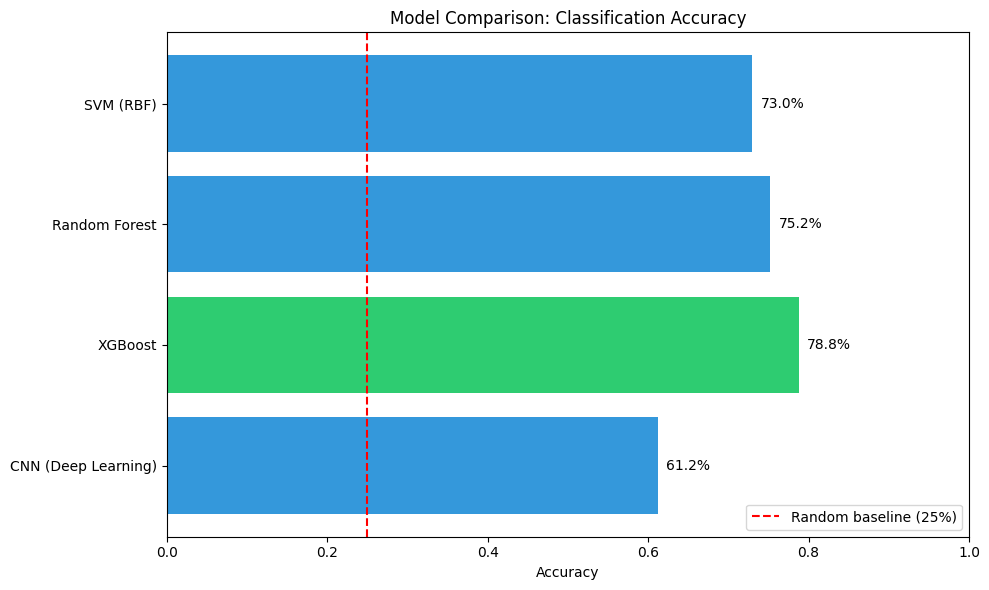

In [ ]:
# Plot accuracy comparison
classifiers = comparison_df[comparison_df['Type'] == 'Classification'].dropna(subset=['Accuracy'])

if len(classifiers) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    colors = ['#2ecc71' if x == classifiers['Accuracy'].max() else '#3498db' 
              for x in classifiers['Accuracy']]
    
    bars = ax.barh(classifiers['Model'], classifiers['Accuracy'], color=colors)
    ax.set_xlabel('Accuracy')
    ax.set_title('Model Comparison: Classification Accuracy')
    ax.set_xlim(0, 1)
    
    # Add value labels
    for bar, acc in zip(bars, classifiers['Accuracy']):
        ax.text(acc + 0.01, bar.get_y() + bar.get_height()/2, 
                f'{acc:.1%}', va='center')
    
    # Add reference line for random baseline (25% for 4 classes)
    ax.axvline(x=0.25, color='red', linestyle='--', label='Random baseline (25%)')
    ax.legend()
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'model_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No classifier results to plot")
